# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np# importar librerías

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [4]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
print(usage.isna().sum()) 
print(usage.isna().mean())# cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**En el data set "users" las columnas "city" y "churn_date" tienen valores nulos. Estos representan el 11% y el 88% respectivamente. Para la columna "city" se recomienda poner nulos datos faltantes, mientras que los datos en "churn_date" se recomiendo ignorarlos ya que no aportan al analisis que se está haciendo.**


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
columnas_numericas_user= ['user_id', 'age']
print(users[columnas_numericas_user].describe())# explorar columnas numéricas de users

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` presenta valores normales, sin tener valores nulos o erroneos.
- La columna `age` si presenta valores invalidos con edades en -999

In [14]:
columnas_numericas_usage= ['id', 'user_id','duration','length']
print(usage[columnas_numericas_usage].describe())# explorar columnas numéricas de usage

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` no presentan valores nulos o sentinels.

In [15]:
# explorar columnas categóricas de users
columnas_categoricas_users = ['city', 'plan']
print(users[columnas_categoricas_users].describe())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` presenta datos faltantes.
- La columna `plan` no presenta problemas.

In [16]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` no presenta problemas.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

**-En la columna "age" en el df "users" presenta sentinels, al igual que en la columna "city" en el df "users" presenta datos faltantes.**

**-Hay que corregir los sentinels y poner datos faltantes como nulos, y la edad cambiarla por la mediana.**

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [19]:
users['año_registro'] = users['reg_date'].dt.year 
print("Años presentes en reg_date:")
print(users['año_registro'].value_counts().sort_index())# Revisar los años presentes en `reg_date` de users


Años presentes en reg_date:
2022    1314
2023    1316
2024    1330
2026      40
Name: año_registro, dtype: int64


En `reg_date`, existen años invalidos, 40 registros en 2026.

In [20]:
usage['año_registro'] = usage['date'].dt.year 
print("Años presentes en date:")
print(usage['año_registro'].value_counts().sort_index())# Revisar los años presentes en `date` de usage


Años presentes en date:
2024.0    39950
Name: año_registro, dtype: int64


En `date`, solo hay registros del año 2024, con 50 entradas faltantes.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**- Existen registros del año 2026, presentan solo 40 registros por lo que hay que ponerlos como valores nulos** 

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
mediana_age = users[users['age'] != -999]['age'].median()
print(f"Mediana de age (sin sentinels): {mediana_age}")

Mediana de age (sin sentinels): 48.0


In [22]:
users['age'] = users['age'].replace(-999, mediana_age)
print(f"Valores -999 después: {(users['age'] == -999).sum()}")
print(f"Mediana usada: {mediana_age}")

Valores -999 después: 0
Mediana usada: 48.0


In [23]:
users['city']= users['city'].replace('?', pd.NA)# Reemplazar ? por NA en city


# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [24]:
año_minimo= 2022 # Marcar fechas futuras como NA para reg_date
año_maximo= 2024
año_fuera_rango= (users['año_registro']< año_minimo) | (users['año_registro']> año_maximo)
users.loc[año_fuera_rango, 'año_registro'] = pd.NA

users['año_registro'].describe()
# Verificar cambios


count     3960
unique       3
top       2024
freq      1330
Name: año_registro, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
proporcion_nulos_duration= usage['duration'].isna().groupby(usage['type']).mean() 
print("Proporción de nulos en duration por type:")
print(proporcion_nulos_duration)
# Verificación MAR en usage (Missing At Random) para duration


Proporción de nulos en duration por type:
type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [26]:
proporcion_nulos_length = usage["length"].isna().groupby(usage["type"]).mean()
print("\nProporción de nulos en length por type:")
print(proporcion_nulos_length) # Verificación MAR en usage (Missing At Random) para length



Proporción de nulos en length por type:
type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**Refleja que son nulos MAR ya que presenta una diferencia casi total porcentual, se tomaran como nulos para mantener la integridad.**

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'length': 'count','duration': ['count','sum']}).reset_index()

# observar resultado
usage_agg.head(3)

user_id length duration       
           count    count    sum
0   10000      7        3  23.70
1   10001      5       10  33.18
2   10002      5        2  10.74

In [28]:
# Renombrar columnas
usage_agg.columns= ['user_id', 'cant_mensajes','cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año_registro,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:
users[columnas_numericas_user].describe()# Resumen estadístico de las columnas numéricas


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.136000
std,1154.844867,17.689919
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,48.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [31]:
users['plan'].value_counts(normalize=True) * 100 # Distribución porcentual del tipo de plan


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

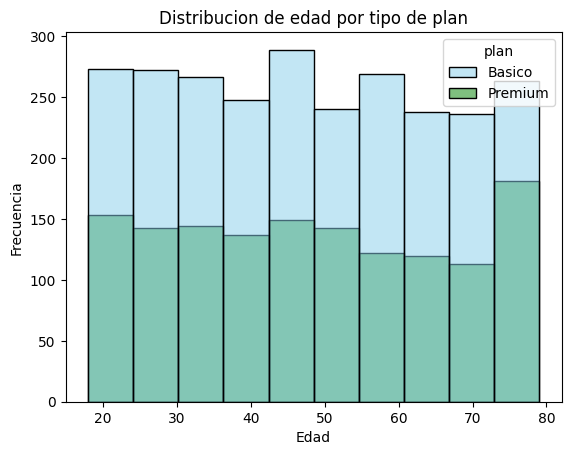

In [32]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age',bins=10, hue='plan', palette= ['skyblue','green'])
plt.title('Distribucion de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Se encuentra una distribución de usuarios dentro de todas las edades con mayor uso de planes básicos dentro de todo el rango. Se observa que en usuarios entre 70 y 80 años, un uso mayor considerable de usuarios premium en comparación con el resto de rango de edades.

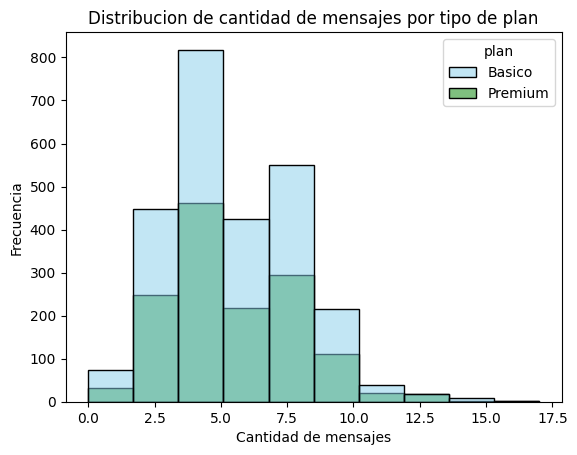

In [33]:
sns.histplot(data=user_profile, x='cant_mensajes',bins=10, hue='plan', palette= ['skyblue','green'])
plt.title('Distribucion de cantidad de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()# Histograma para visualizar la cant_mensajes






💡Insights: 
- El pico de actividad para ambos grupos se encuentra entre los 2.5 y 5 mensajes. Después de los 7.5 mensajes, la frecuencia cae drásticamente. Muy pocos usuarios envían más de 12.5 mensajes, independientemente de su plan. Casi no existen usuarios en el rango de 15 a 17.5 mensajes. Tiene una ligero sesgo hacia la derecha.

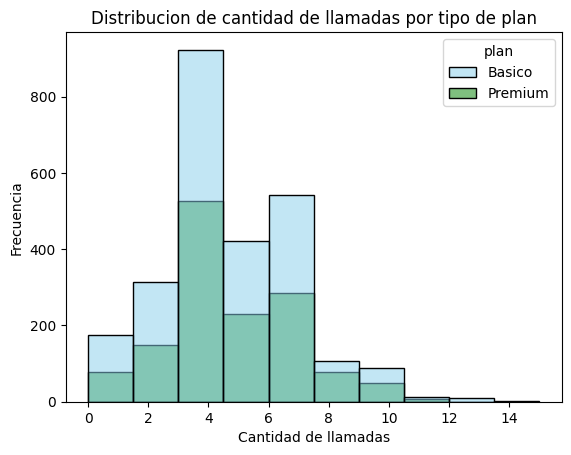

In [34]:
sns.histplot(data=user_profile, x='cant_llamadas',bins=10, hue='plan', palette= ['skyblue','green'])
plt.title('Distribucion de cantidad de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()# Histograma para visualizar la cant_llamadas


💡Insights: 
- La gran mayoría de los clientes, independientemente del plan, realizan entre 2 y 8 llamadas. Después de las 9 llamadas, la frecuencia cae drásticamente para ambos grupos. Hay un descenso notable en la frecuencia de llamadas en el rango de 4.5 a 6, seguido de un pequeño repunte entre 6 y 7.5. De igual forma hay un ligero sesgo hacia la derecha.

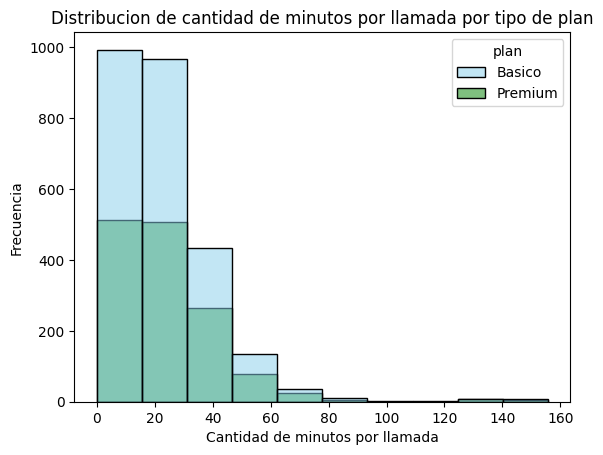

In [35]:
sns.histplot(data=user_profile, x='cant_minutos_llamada',bins=10, hue='plan', palette= ['skyblue','green'])
plt.title('Distribucion de cantidad de minutos por llamada por tipo de plan')
plt.xlabel('Cantidad de minutos por llamada')
plt.ylabel('Frecuencia')
plt.show()# Histograma para visualizar la cant_minutos_llamada


💡Insights: 
- Hay una mayor cantidad de llamadas realizados por usuarios del plan Básico en comparación con el Premium, o que la muestra de datos está sesgada hacia ese grupo. La gran mayoría de las llamadas son cortas, concentrándose entre 0 y 40 minutos. A medida que aumenta la duración, la frecuencia cae drásticamente. Hay presencia de valores atípicos, existen llamadas que superan los 120 y hasta 140 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

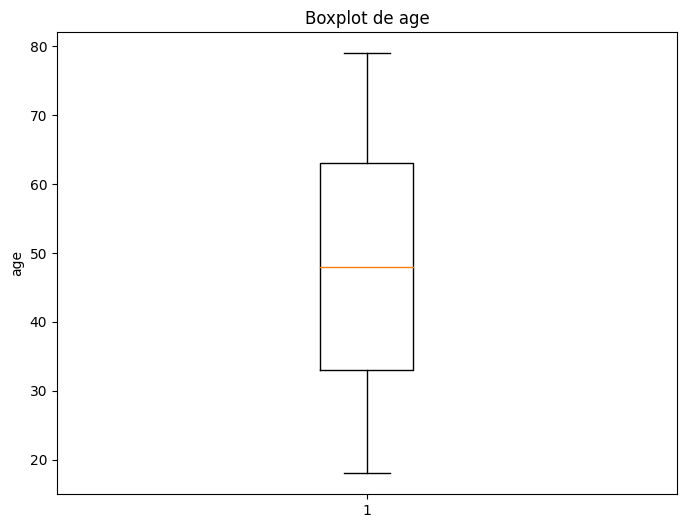

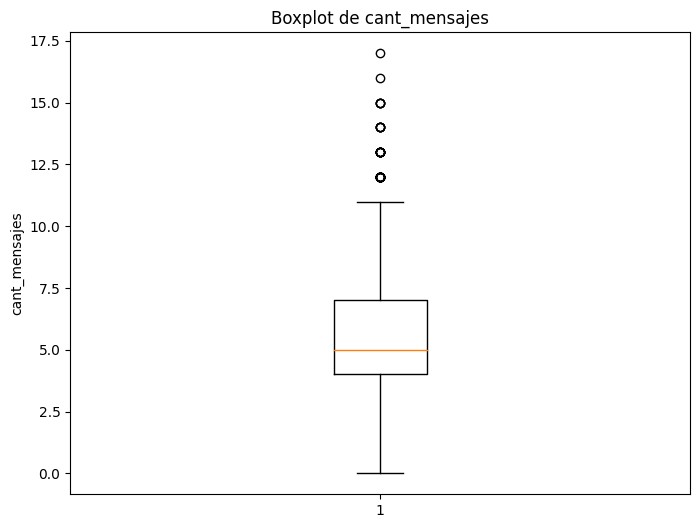

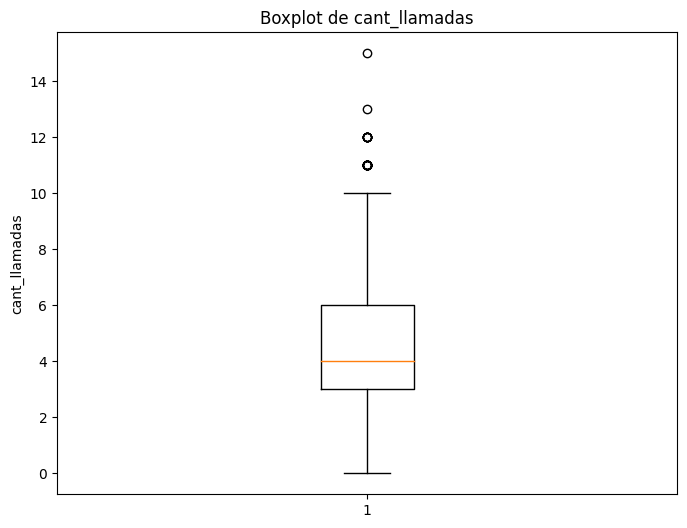

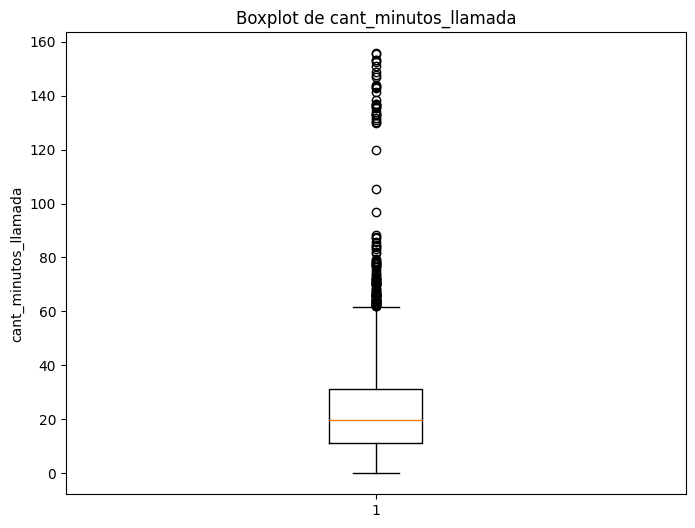

In [36]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 6))
    plt.boxplot(user_profile[col].dropna()) 
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)
    plt.show()

💡Insights: 
- Age: No presenta outliers.
- cant_mensajes: Presenta outliers
- cant_llamadas: Presenta outliers
- cant_minutos_llamada: Presenta outliers

In [37]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas', 'cant_minutos_llamada']
for col in columnas_numericas:
    Q1= user_profile[col].quantile(0.25)
    Q3= user_profile[col].quantile(0.75)
    IQR= Q3 - Q1

    limite_inferior= Q1 - 1.5 * IQR
    limite_superior= Q3 + 1.5 * IQR

    outliers_inferiores= (user_profile[col] < limite_inferior).sum()
    outliers_superiores= (user_profile[col] > limite_superior).sum()

    if outliers_inferiores > 0 or outliers_superiores > 0:
        columnas_limites.append(col)
        print(f"{col}: {outliers_inferiores} outliers inferiores, {outliers_superiores} outliers superiores")



cant_mensajes: 0 outliers inferiores, 46 outliers superiores
cant_llamadas: 0 outliers inferiores, 30 outliers superiores
cant_minutos_llamada: 0 outliers inferiores, 109 outliers superiores


In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,5.527382,4.482121,23.317054,5.527382,4.482121,23.317054
std,2.358383,2.145092,18.168095,2.358383,2.145092,18.168095
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Mantendría los outliers ya que no significan una cantidad considerable de datos extremos.
- cant_llamadas: Mantendría los outliers ya que no significan una cantidad considerable de datos extremos.
- cant_minutos_llamada: Los eliminaría para mantener la integridad de uso de los usuarios promedio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [39]:
user_profile['grupo_uso']= np.where((user_profile['cant_llamadas'] <5) & (user_profile['cant_mensajes'] <5), 'Bajo uso',np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 
        'Uso medio', 'Alto uso' )) # Crear columna grupo_uso


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año_registro,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [41]:
user_profile['grupo_edad'] = np.where(user_profile['age'] < 30, 'Joven', np.where(user_profile['age'] < 60, 'Adulto', 'Adulto Mayor'))


In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año_registro,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

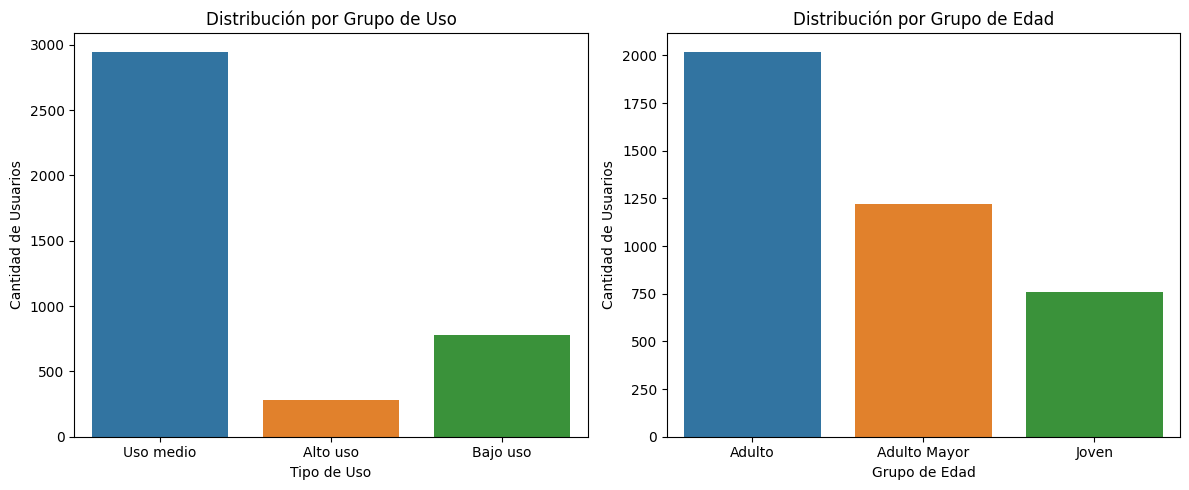

In [43]:
# Visualización de los segmentos por uso y edad
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=user_profile, x='grupo_uso', ax=axes[0])
axes[0].set_title('Distribución por Grupo de Uso')
axes[0].set_xlabel('Tipo de Uso')
axes[0].set_ylabel('Cantidad de Usuarios')

sns.countplot(data=user_profile, x='grupo_edad', ax=axes[1])
axes[1].set_title('Distribución por Grupo de Edad')
axes[1].set_xlabel('Grupo de Edad')
axes[1].set_ylabel('Cantidad de Usuarios')

plt.tight_layout()
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se encontraron 40 registros con una fecha imposible (2026) ya que la base de datos está basada en el año 2024, mostrando una falla de captura ó falla de sistema.
- De igual manera, existen valores sentinel en la columna "age" con valores -999.
- En la columna "city" se encuentran otro sentinel "?" dando resultados de ciudades no registradas, aproximadamente un 11% de los usuarios carecian de una ciudad en el registro.
- Se encontraron 50 registros en el dataset de uso que no tenían fecha asociada (date nulo), lo que impedía su asignación a un periodo específico del año 2024.
- Las columnas de fecha (reg_date y date) estaban cargadas como objetos de texto y no como tipos de tiempo (datetime), lo que impedía realizar cálculos de antigüedad o tendencias mensuales sin una conversión previa.


🔍 **Segmentos por Edad**
- Encontramos que la edad promedio de los usuarios es de 48 años, la base de usuarios se concentra en un rango de adultos maduros (entre 32 y 63 años según los percentiles 25% y 75%). Este grupo suele tener mayor poder adquisitivo y menor tasa de rotación espontánea en comparación con segmentos más jóvenes. Son candidatos ideales para estrategias de retención de largo plazo y para la venta de planes Premium o servicios adicionales de hogar.
- Los usuarios con una edad mayor (llegando al limite de los 79) mantienen un uso de consumo estable, mientras que el grueso de consumo y uso se concentra en adultos de mediana edad (40-55 años)


📊 **Segmentos por Nivel de Uso**
- Existen 2 segmentos principales: el básico y el premium
- En el segmento básico se observa un uso mayoritario que representa un 65% de la base de usuarios. El comportamiento en este segmento es un poco limitado por las caracteristicas que presenta su plan, es el grupo que sugiere un mayor riesgo de generar gastos adicionales o de requerir una migración, haciendolos un segmento valioso por el gasto extra que se puede generar al exceder los limites del plan basico sugiriendo alta rentabilidad.
- Mientras el límite del Plan Básico es de 5GB, hay usuarios que alcanzan consumos significativamente superiores, pagando hasta $1.2 USD por cada GB adicional. Estos usuarios son altamente rentables en el corto plazo debido a los cargos por excedentes, pero tienen un alto riesgo de fuga (churn). Si un competidor les ofrece un plan ilimitado a un precio menor que lo que pagan hoy por excedentes, se irán.
- El segmento premium representa el 35% de los usuarios. Usuarios con mayor capacidad de consumo. Este segmento es menos sensible a los cargos por exceso de uso debido a los amplios límites de su plan. 
- Aunque el sistema registra las llamadas y los mensajes por separado, la mayoría de los usuarios consumen ambos servicios, con una ligera inclinación hacia el uso de mensajería de texto (22,092 registros de texto vs. 17,908 de llamadas en la muestra).

💡 **Recomendaciones**
- Crear un plan intermedio ó más flexible que incluya una mejora en GB, mensajes y minutos. Un plan intermedio reduciría la fricción para los usuarios que exceden el minimo en GB pero no llegan a consumir los 20 GB del Premium, de igual manera en mensajes, evitando que sientan que pagan de más por servicios que no usan.
- Indentificar los usuarios que exceden constantemente exceden su límite de su plan y promover el plan premium con algún plan de bienvenida dando descuento inicial en los primeros meses de migración al nuevo plan, haciéndolo mucho más atractivo y haciéndolo una opción para el cliente. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`